# LDA (продолжение)

In [3]:
import numpy as np
import pandas as pd
from pprint import pprint
import gensim
from gensim import corpora
from gensim.models import LdaModel

import csv
import pickle # Для сохранения словаря, корпуса и модели

## Загрузка исходных данных(__data__)лемматизированного текста(__loaded_text__), словаря(__dictionary__), корпуса(__corpus__) и модели(__lda_model__)

In [40]:
from sklearn.datasets import fetch_20newsgroups
newsgroups_train = fetch_20newsgroups(subset='train')
data = newsgroups_train.data

In [ ]:
with open('lemmatized_txt.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    # next(reader)  # Пропуск заголовка, если при записи мы его вставили: 
    loaded_text = [row[0] for row in reader]
    
    # with open('lemmatized_text.csv', 'w', newline='', encoding='utf-8') as f:
        # writer = csv.writer(f)
        # writer.writerow(['word'])  # Заголовок
        # for word in lemmatized_text:
            # writer.writerow([word])

In [6]:
loaded_text[:2]


["['lerxst', 'wam_umd', 'thing', 'car', 'nntp_posting', 'host', 'rac_wam', 'umd', 'organization', 'university', 'maryland_college', 'park', 'line', 'wonder', 'anyone', 'could', 'enlighten', 'car', 'saw', 'day', 'door', 'sport', 'car', 'look', 'late', 'early', 'call', 'bricklin', 'door', 'really', 'small', 'addition', 'front_bumper', 'separate', 'rest', 'body', 'know', 'anyone', 'tellme', 'model', 'name', 'engine', 'spec', 'year', 'production', 'car', 'make', 'history', 'whatever', 'info', 'funky', 'look', 'car', 'please', 'mail', 'thanks', 'il', 'bring', 'neighborhood', 'lerxst']",
 "['guykuo_carson', 'washington', 'guy_kuo', 'si', 'clock', 'poll', 'final', 'call', 'summary', 'final', 'call', 'si', 'clock', 'report', 'keywords', 'si', 'acceleration', 'clock', 'upgrade', 'article', 'shelley', 'qvfo', 'innc', 'organization', 'university', 'washington', 'line', 'nntp_posting', 'host', 'carson_washington', 'fair', 'number', 'brave', 'soul', 'upgrade', 'si', 'clock', 'oscillator', 'share', 

In [2]:
# Загрузка словаря
dictionary = corpora.Dictionary.load('dictionary.dict')

In [ ]:
pprint(dictionary.token2id)

In [ ]:
# Загрузка корпуса
with open('corpus.pkl', 'rb') as f:
    corpus = pickle.load(f)

In [ ]:
print(type(corpus))
print(corpus[0])

In [26]:
# Загрузка модели
lda_model = LdaModel.load('lda_model.model')

In [ ]:
topics=lda_model.show_topics(num_topics=25, num_words=10,formatted=False)
topics

## Поиск доминирующих тем в документах (<font color='lightgreen'>optimal_model</font>)
### Определение номера темы, которая имеет наибольший процентный вклад в конкретный документ.

### Поиск доминирующих тем

#### Функция <font color='lightgreen'><big>get_top_topics</big></font>   


In [9]:
# Вывод нескольких (top_n) доминирующих тем для каждого документа
def get_top_topics(lda_model, corpus, top_n):
    top_topics_list = []
    for doc in corpus:
        topic_probs = lda_model.get_document_topics(doc)
        top_topics = sorted(topic_probs, key=lambda x: x[1], reverse=True)[:top_n]
        top_topics_list.append([topic[0] for topic in top_topics])
    return top_topics_list

#### как работает функция <font color='lightgreen'><big>get_top_topics</big></font>   

1. Входные параметры:  
- <font color='lightgreen'>lda_model</font> - обученная модель LDA (LdaModel), которая может генерировать вероятности тем для каждого документа.  
- <font color='lightgreen'>corpus</font> - корпус документов, представленный в виде мешка слов (bag-of-words), где каждый документ представлен как список пар (идентификатор слова, частота).  

- <font color='lightgreen'>top_n=2</font> - сколько доминирующих тем будем оценивать  
1. <font color='lightgreen'>top_topics_list</font> - (изачально пустой) будет хранить индексы доминирующих тем для каждого документа.  
2. <font color='lightgreen'>for doc in corpus</font> - для каждого документа в корпусе вычисляются вероятности принадлежности документа к каждой теме с помощью метода get_document_topics:  
   - <font color='lightgreen'>topic_probs = lda_model.get_document_topics(doc)</font>  
который возвращает список пар (topic_id, probability), где topic_id — индекс темы, а probability — вероятность того, что документ относится к данной теме.  
    - <font color='lightgreen'>top_topics = sorted(topic_probs, key=lambda x: x[1], reverse=True)[:top_n]</font>  
    -   
        Разбор процесса сортировки:  
        Данные для сортировки:
        - topic_probs — список пар вида (topic_id, probability)  
        - Функция sorted: сортирует список на основе критерия, указанного через параметр key.
            - __key=lambda x: x[1]__, где x — это каждый элемент списка topic_probs (например, (0, 0.2)), x[1] извлекает вероятность (probability) из пары (topic_id, probability). Т.о., сортировка производится по второму элементу каждой пары, то есть по вероятности.  
            - __reverse=True__: список сортируется в порядке убывания.  
            - __[:top_n]__ После сортировки оператор [:top_n] извлекает первые top_n элементов из отсортированного списка, что соответствует top_n наиболее вероятным темам.

    - <font color='lightgreen'>top_topics_list.append([topic[0] for topic in top_topics])</font>  
Индексы доминирующих тем для текущего документа добавляются в список dominant_topics.

#### вызов ф-ции

In [33]:
top_topics_list = get_top_topics(lda_model, corpus, top_n=1)

#### Результат

In [ ]:
# Вывод результатов (10 документов на выбор)
print("Top topics in each document:")
for i, topics in enumerate(top_topics_list[7:17]):
    print(f"Document {i + 1}: Topics {topics}")

## Поиск документов, наиболее полно отражающих выбранную тему -> <font color='lightgreen'>relevant_docs</font>


In [75]:
# Найти документы, наиболее полно отражающие выбранную тему
def get_documents_for_topic(lda_model, corpus, topic_id, top_n):
    topic_scores = []
    for doc_index, doc in enumerate(corpus):
        # doc_index:- индекс текущего документа в corpus.
        # doc - документ, представленный в формате "мешка слов", а это список кортежей, где:
        # первый элемент кортежа — идентификатор слова (число, сопоставленное слову в словаре dictionary).
        # второй элемент — частота слова в документе.
        topic_probs = lda_model.get_document_topics(doc)
        # Здесь происходит трансформация, мы имеем дело уже не с мешком слов,
        # а с темами и отнесением документа к теме.
        
        # возвращает список пар (topic_id, probability), 
        # где topic_id — индекс темы, 
        # probability — вероятность того, что документ относится к данной теме. 
        for topic, prob in topic_probs:
        # Пробегаемся по списку из кортежей, в каждом из которых: 
        # в topic - индекс темы, 
        # в prob - вероятность того, что документ относится к данной теме.
        
        # в этом списке кортежей тема встречается не более одного раза (т.е. может вообще не встечатся?)
            if topic == topic_id:
            # если индекс темы совпал с запрошенным
                topic_scores.append((doc_index, prob))
                # добавляем индекс текущего документа 
                # и вероятность относения документа к данной теме.
                break
        # Т.о., topic_scores - это список из кортежей, в каждом из которых 
        
    # Сортируем документы по убыванию вероятности выбранной темы
    top_docs = sorted(topic_scores, key=lambda x: x[1], reverse=True)[:top_n]
    return top_docs

In [76]:
selected_topic = 0  # Выбранная тема
relevant_docs = get_documents_for_topic(lda_model, corpus, selected_topic, top_n=3)

In [43]:
# Выводит идентификаторы документов и вероятности их принадлежности к выбранной теме
relevant_docs

[(12, 0.39870435), (3845, 0.29207262), (6209, 0.28570518)]

In [77]:
# Вывод результатов (с текстом документов)
print(f"Top documents for topic {selected_topic}:")
for doc_index, score in relevant_docs:
    print(f"Document {doc_index}: Score {score:.4f}\nContent: {data[doc_index]}")

Top documents for topic 0:
Document 12: Score 0.3986
Content: From: rodc@fc.hp.com (Rod Cerkoney)
Subject: *$G4qxF,fekVH6
Nntp-Posting-Host: hpfcmrc.fc.hp.com
Organization: Hewlett Packard, Fort Collins, CO
X-Newsreader: TIN [version 1.1 PL8.5]
Lines: 15



--


Regards,
Rod Cerkoney
                                                        /\
______________________________________________         /~~\
                                                      /    \
  Rod Cerkoney MS 37     email:                      /      \ 
  Hewlett Packard         rodc@fc.hp.com        /\  /        \  
  3404 East Harmony Rd.  Hpdesk:               /  \/          \    /\
  Fort Collins, CO 80525  HP4000/UX           /    \           \  /  \
_____________________________________________/      \           \/    \__

Document 3845: Score 0.2921
Content: From: keith@cco.caltech.edu (Keith Allan Schneider)
Subject: Re: Political Atheists?
Organization: California Institute of Technology, Pasadena
Lines: 11


### Каков список топ-слов для выбранной темы.

In [78]:
def get_top_words_for_topic(lda_model, topic_id, num_words):
    # param lda_model: Обученная модель LDA
    # param topic_id: Идентификатор темы
    # param num_words: Количество топ-слов для возврата
    # Получаем топ-слова для выбранной темы
    topic = lda_model.show_topic(topic_id, num_words)
    # Метод show_topic(topic_id, num_words) возвращает список из num_words топ-слов для указанной темы (topic_id - ее идентификатор).
    # Каждое слово представлено в виде кортежа (слово, вероятность), 
    # где вероятность — это значение, связанное с важностью слова для данной темы.
    
    # return: Список кортежей (слово, вероятность)
    return topic

In [79]:
selected_one_topic = 0  # Выбранная тема
num_words = 10      # Количество топ-слов
top_words_one_topic = get_top_words_for_topic(lda_model, selected_one_topic, num_words)
top_words_one_topic

[('hp', 0.05270272),
 ('de', 0.04615069),
 ('md', 0.040655043),
 ('newsreader_tin', 0.038019117),
 ('la', 0.033497967),
 ('version_pl', 0.029823968),
 ('dave', 0.026527455),
 ('sc', 0.02132477),
 ('mot', 0.018256212),
 ('caltech', 0.017754912)]

In [80]:
# Вывод топ-слов для выбранной темы
print(f"Top {num_words} words for topic {selected_one_topic}:")
for word, prob in top_words_one_topic:
    print(f"{word}: {prob:.4f}")


Top 10 words for topic 0:
hp: 0.0527
de: 0.0462
md: 0.0407
newsreader_tin: 0.0380
la: 0.0335
version_pl: 0.0298
dave: 0.0265
sc: 0.0213
mot: 0.0183
caltech: 0.0178


### Список топ-слов для выбранной темы в формате датафрейма


In [48]:
# Возвращает DataFrame с топ-словами и их вероятностями для выбранной темы.

def get_top_words_dataframe(lda_model, topic_id, num_words=10):
    # param: lda_model - Обученная модель LDA
    # param: topic_id - Идентификатор темы
    # param: num_words - Количество топ-слов для возврата
    
    # Получаем топ-слова для выбранной темы
    top_words = lda_model.show_topic(topic_id, num_words)
    
    # Создаем DataFrame
    df = pd.DataFrame(top_words, columns=['Word', 'Probability'])
    
    # return DataFrame с колонками 'Word' и 'Probability'
    return df

In [49]:
selected_topic_pd = 0  # Выбранная тема
num_words = 10      # Количество топ-слов
top_words_df = get_top_words_dataframe(lda_model, selected_topic_pd, num_words=num_words)

In [ ]:
# Вывод DataFrame
print(f"Top {num_words} words for topic {selected_topic_pd}:")
print(top_words_df)

__________ опционально ... ___________

In [ ]:
# Вывод топ-слов для каждой темы
print("\nTop words for each topic:")
for i, topic in enumerate(lda_model.show_topics(num_topics=20, num_words=5, formatted=True)):
    print(f"Topic {i}: {topic[1]}")

## Оценка распределения тем по документам.

In [82]:
import matplotlib.pyplot as plt

topic_distributions = [lda_model.get_document_topics(doc) for doc in corpus]
    # возвращает список пар (topic_id, probability), 
    # где topic_id — индекс темы, 
    # probability — вероятность того, что документ относится к данной теме. 
    # len(topic_distributions) # 11314
    # topic_distributions
    # lda_model.num_topics # 25

In [83]:
# Преобразование распределений в табличный формат
# Каждый документ представлен вектором вероятностей для тем
topic_matrix = np.zeros((len(topic_distributions), lda_model.num_topics))
# topic_matrix
for i, doc_topics in enumerate(topic_distributions):
    for topic_id, prob in doc_topics:
        topic_matrix[i, topic_id] = prob

Как работает.  
1. Внешний цикл.  
   - в i - номер документа,  
   - в  doc_topics - список кортежей вида (№ темы, вероятность).  
   - т.к. тем - 25 - то и кортежей 25.
На первом проходе берем номер темы и список кортежей.  
1. Внутренний цикл.  
    - проходимся поочередно по 25 кортежам вытаскивая № темы и вероятность.  
    - в заготовленную матрицу заносим вероятность на позицию: 
        - № строки  = i - номер документа,
        - № столбца = topic_id - номер темы.



In [84]:
topic_df = pd.DataFrame(topic_matrix, columns=[f"Topic {i}" for i in range(lda_model.num_topics)])
topic_df.head()

,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,...,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20,Topic 21,Topic 22,Topic 23,Topic 24
0,0.000000,0.0,0.041255,0.000000,0.047050,0.170229,0.000000,0.197790,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.283496,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.0,0.000000,0.000000,0.050297,0.020316,0.046029,0.343385,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.126845,0.000000,0.000000,0.000000,0.016144
2,0.103672,0.0,0.041569,0.000000,0.046117,0.000000,0.010972,0.159907,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.530432,0.000000,0.000000,0.000000,0.000000
3,0.027753,0.0,0.000000,0.000000,0.077328,0.018423,0.055021,0.293515,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.233310,0.102813,0.000000,0.000000,0.018844
4,0.000000,0.0,0.108673,0.013528,0.082901,0.000000,0.039956,0.177293,0.0,0.0,...,0.0,0.0,0.102562,0.022983,0.021971,0.215831,0.000000,0.011082,0.039655,0.000000


In [85]:
topic_df['Dominant Topic'] = topic_df.idxmax(axis=1)

Что делает idxmax(axis=1):
    - вычисляет индекс столбца с максимальным значением (для каждой строки, т.е. для каждого документа).
    - axis=1 указывает, что операция выполняется по строкам.
Возвращает название столбца (например, Topic 0, Topic 1, ...) с максимальной вероятностью для каждой строки.

В итоге добавляется еще одиин столбец - 'Dominant Topic'

In [68]:
topic_df.head()

,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,...,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20,Topic 21,Topic 22,Topic 23,Topic 24,Dominant Topic
0,0.000000,0.0,0.041257,0.000000,0.047040,0.170235,0.000000,0.197798,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.283497,0.000000,0.000000,0.000000,0.000000,Topic 20
1,0.000000,0.0,0.000000,0.000000,0.050299,0.020314,0.046028,0.343386,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.126845,0.000000,0.000000,0.000000,0.016144,Topic 7
2,0.103672,0.0,0.041569,0.000000,0.046117,0.000000,0.010971,0.159908,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.530432,0.000000,0.000000,0.000000,0.000000,Topic 20
3,0.027753,0.0,0.000000,0.000000,0.077328,0.018415,0.055021,0.293524,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.233309,0.102813,0.000000,0.000000,0.018844,Topic 7
4,0.000000,0.0,0.108674,0.013528,0.082901,0.000000,0.039956,0.177293,0.0,0.0,...,0.0,0.102562,0.022983,0.021971,0.215831,0.000000,0.011082,0.039655,0.000000,Topic 20


In [70]:

# Подсчет количества документов по доминирующим темам
topic_counts = topic_df['Dominant Topic'].value_counts()

In [71]:
topic_counts

Dominant Topic
Topic 20    6992
Topic 7     2176
Topic 10     977
Topic 4      749
Topic 24     109
Topic 5      102
Topic 2       67
Topic 6       43
Topic 23      35
Topic 12      19
Topic 14      10
Topic 0        7
Topic 19       6
Topic 13       5
Topic 1        5
Topic 9        4
Topic 3        4
Topic 16       1
Topic 18       1
Topic 8        1
Topic 11       1
Name: count, dtype: int64

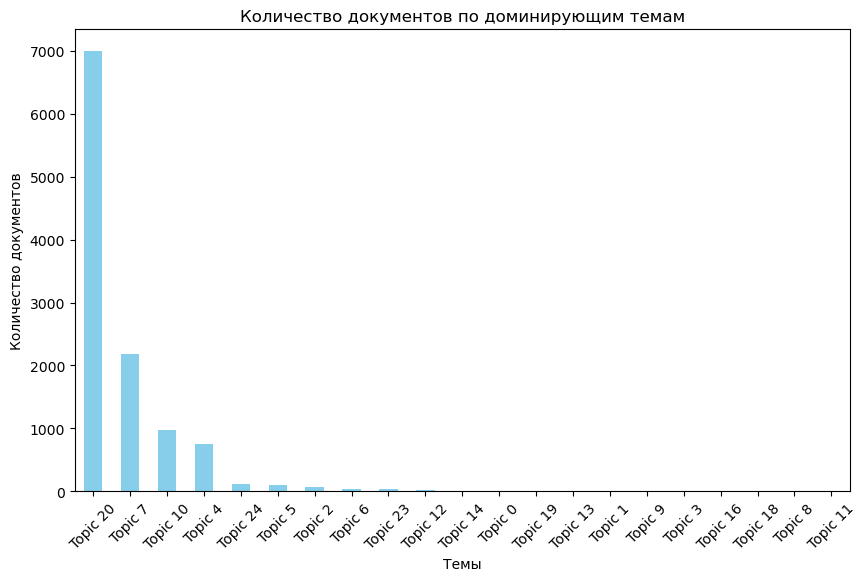

In [72]:
# Визуализация распределения тем
plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar', color='skyblue')
plt.title('Количество документов по доминирующим темам')
plt.xlabel('Темы')
plt.ylabel('Количество документов')
plt.xticks(rotation=45)
plt.show()

In [73]:
# Расчет среднего распределения тем по всем документам
average_topic_distribution = topic_df.iloc[:, :-1].mean(axis=0)

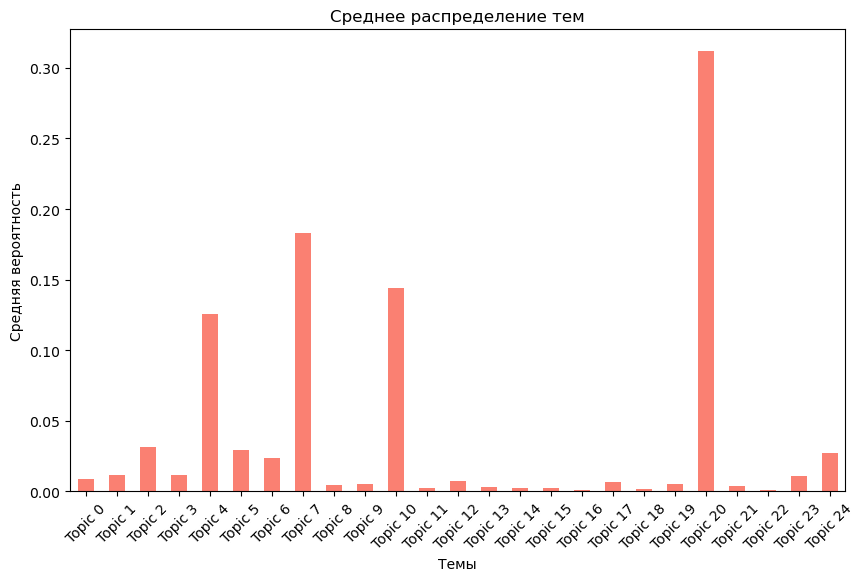

In [74]:
# Визуализация среднего распределения тем
plt.figure(figsize=(10, 6))
average_topic_distribution.plot(kind='bar', color='salmon')
plt.title('Среднее распределение тем')
plt.xlabel('Темы')
plt.ylabel('Средняя вероятность')
plt.xticks(rotation=45)
plt.show()